# LIBRARY

In [1]:
import gzip
import pickle
import ast
 
import numpy as np
import pandas as pd
from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN

# PREPARATION

## LOAD DATASET

In [37]:
MOTIFS_CSV   = "../1.DATASET/motifs_discords.csv"
DATASET_PATH = "../1.DATASET/CMI_timeseries_personalized.pkl.gz"
CHANNELS     = ["X", "Y", "Z", "enmo", "anglez", "light"]
W            = 17
COLS_TO_DROP = ["battery_voltage", "timestamp", "quarter",
                "relative_date_PCIAT", "non-wear_flag", "weekday"]
 
# Set to True to also include discord windows in the feature vector
# Recommendation: start with False — motifs are more stable and interpretable
USE_DISCORDS = False

In [38]:
with gzip.open(DATASET_PATH, "rb") as f:
    CMI = pickle.load(f)

data_clean = [df.drop(columns=COLS_TO_DROP, errors="ignore") for df in CMI]
print(f"  {len(data_clean)} subjects loaded")


  4307 subjects loaded


In [39]:
# ── Extract sii_binary labels (one per subject, before dropping columns) ──
y_labels = np.array([
    df["sii_binary"].dropna().iloc[0]   # same value repeated for all rows
    if "sii_binary" in df.columns else np.nan
    for df in CMI
], dtype=float)

print(f"  Labels extracted: {len(y_labels)} subjects")
print(f"  label=0: {(y_labels==0).sum()}  label=1: {(y_labels==1).sum()}  NaN: {np.isnan(y_labels).sum()}")

  Labels extracted: 4307 subjects
  label=0: 2887  label=1: 1420  NaN: 0


## NORMALIZATION

In [40]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

In [41]:
def fit_global_scalers(df_list, signals):
    """Fit one RobustScaler per signal using TRAIN data only."""
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers


In [42]:
def apply_global_scalers(df_list, global_scalers):
    """Apply pre-fitted scalers to a list of DataFrames."""
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list


In [43]:
global_scalers = fit_global_scalers(data_clean, signals)

all_scaled = apply_global_scalers(
    data_clean,
    global_scalers
)

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8341)
  Y                  → RobustScaler   (IQR=0.4156)
  Z                  → RobustScaler   (IQR=0.4314)
  enmo               → RobustScaler   (IQR=0.0454)
  anglez             → RobustScaler   (IQR=5.6440)
  light              → RobustScaler   (IQR=1.8208)


## LOAD MOTIF DATASET

In [44]:
print("Loading motifs CSV …")
motifs_df = pd.read_csv(MOTIFS_CSV)

# Parse stringified lists safely
for col in motifs_df.columns:
    if col != "sample_index":
        motifs_df[col] = motifs_df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

Loading motifs CSV …


## SIGNAL RETRIEVAL

In [45]:
# For every subject, for every channel, pull the raw windows
# at each motif start index  →  store as fixed-length vectors

In [46]:
def extract_windows(ts: np.ndarray, indices: list[int], w: int) -> list[np.ndarray]:
    """Return list of length-w windows; skip any that go out of bounds."""
    windows = []
    for idx in indices:
        if idx + w <= len(ts):
            windows.append(ts[idx: idx + w])
    return windows

In [47]:
def motif_medoid(windows: list) -> np.ndarray:
    """Restituisce la finestra più centrale (medoid) tra quelle disponibili."""
    if len(windows) == 0:
        return None
    if len(windows) == 1:
        return windows[0]
    X = np.vstack(windows)                    # (n_motifs, W)
    D = cdist(X, X, metric="euclidean")
    medoid_idx = np.argmin(D.sum(axis=1))
    return X[medoid_idx]   

In [48]:
records = []

for _, row in motifs_df.iterrows():
    subj_idx = int(row["sample_index"])
    df_subj  = all_scaled[subj_idx]

    subj_features = {"sample_index": subj_idx}

    for ch in CHANNELS:
        if ch not in df_subj.columns:
            subj_features[f"{ch}_motif_medoid"]   = np.zeros(W)
            subj_features[f"{ch}_discord_medoid"] = np.zeros(W)
            continue

        ts           = df_subj[ch].values.astype(float)
        motif_idxs   = row[f"{ch}_motifs"]
        discord_idxs = row[f"{ch}_discords"]

        motif_wins   = extract_windows(ts, motif_idxs,   W)
        discord_wins = extract_windows(ts, discord_idxs, W)

        subj_features[f"{ch}_motif_medoid"]   = (
            motif_medoid(motif_wins)   if motif_wins   else np.zeros(W)
        )
        subj_features[f"{ch}_discord_medoid"] = (
            motif_medoid(discord_wins) if discord_wins else np.zeros(W)
        )

    records.append(subj_features)

print(f"  Built {len(records)} subject records")

  Built 4307 subject records


## BUILD 3D FEATURE MATRIX

In [49]:
if USE_DISCORDS:
    X_3d = np.array([
        np.hstack([
            np.stack([r[f"{ch}_motif_medoid"]   for ch in CHANNELS], axis=1),
            np.stack([r[f"{ch}_discord_medoid"] for ch in CHANNELS], axis=1),
        ])
        for r in records
    ])
    print(f"Feature matrix shape (motifs + discords): {X_3d.shape}")
else:
    X_3d = np.array([
        np.stack([r[f"{ch}_motif_medoid"] for ch in CHANNELS], axis=1)
        for r in records
    ])
    print(f"Feature matrix shape (motifs only): {X_3d.shape}")

Feature matrix shape (motifs only): (4307, 17, 6)


# CLUSTERING k-means

## precompute dtw distance matrix

In [15]:
print("Computing DTW distance matrix (this may take a while) ...")
sakoe_radius = 10 # max(1, int(0.05 * W))
dist_mat = cdist_dtw(
    X_3d,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=sakoe_radius
)
print(f"  Distance matrix shape: {dist_mat.shape}")

Computing DTW distance matrix (this may take a while) ...
  Distance matrix shape: (4307, 4307)


## elbow

In [16]:
k_range  = range(2, 17)
sse_list = []
sil_list = []

print("Sweeping k ...")
for k in k_range:
    print(f"  Calculating {k}-means ...")
    km = TimeSeriesKMeans(
    n_clusters=k,
    metric="dtw",
    metric_params={"global_constraint": "sakoe_chiba", "sakoe_chiba_radius": 10},
    n_init=1,
    max_iter=500,
    random_state=42,
    n_jobs=-1      # moved directly into the constructor
    )
    #km.set_config(**{"backend:parallel": "loky", "n_jobs": -1})
    km.fit(X_3d)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(dist_mat, km.labels_, metric="precomputed"))
    print(f"    inertia={km.inertia_:,.2f}  silhouette={sil_list[-1]:.4f}")

Sweeping k ...
  Calculating 2-means ...
    inertia=202.04  silhouette=0.9869
  Calculating 3-means ...
    inertia=182.89  silhouette=0.5886
  Calculating 4-means ...
    inertia=164.85  silhouette=0.4715
  Calculating 5-means ...
    inertia=140.13  silhouette=0.4499
  Calculating 6-means ...
    inertia=131.80  silhouette=0.3018
  Calculating 7-means ...
    inertia=102.31  silhouette=0.1537
  Calculating 8-means ...
    inertia=102.55  silhouette=0.4059
  Calculating 9-means ...
    inertia=93.69  silhouette=0.2412
  Calculating 10-means ...
    inertia=89.35  silhouette=0.1459
  Calculating 11-means ...
    inertia=85.94  silhouette=0.1587
  Calculating 12-means ...
    inertia=81.61  silhouette=0.1642
  Calculating 13-means ...
    inertia=78.66  silhouette=0.1077
  Calculating 14-means ...
    inertia=75.51  silhouette=0.1092
  Calculating 15-means ...
    inertia=72.77  silhouette=0.1056
  Calculating 16-means ...
    inertia=70.86  silhouette=0.1061


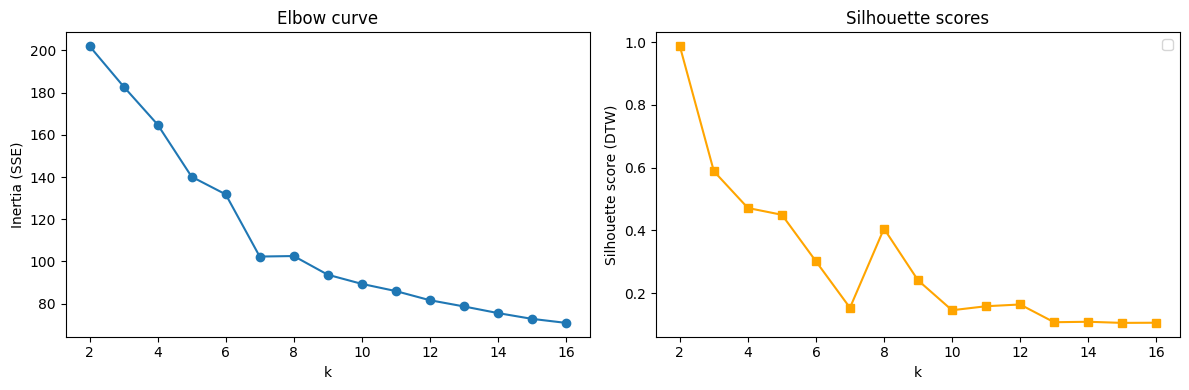

In [17]:
# ──  Elbow + Silhouette ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), sse_list, "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow curve")

axes[1].plot(list(k_range), sil_list, "s-", color="orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score (DTW)")
axes[1].set_title("Silhouette scores")
# mark automatic best for reference, but you can override
auto_best_k = list(k_range)[int(np.argmax(sil_list))]
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
best_k = 8

# final fit with best k

In [19]:
km_final = TimeSeriesKMeans(
    n_clusters    = best_k,
    metric        = "dtw",
    metric_params = {
        "global_constraint"  : "sakoe_chiba",
        "sakoe_chiba_radius" : 10              # 10 steps = 5% of 200 timesteps
    },
    n_init        = 5,
    max_iter      = 500,
    random_state  = 42,
    n_jobs        = -1
)

km_final.fit(X_3d)
cluster_labels = km_final.labels_



In [20]:
series_length   = 200         # your timestep count
window_fraction = 0.05         # your original 5% window
sakoe_chiba_radius = int(series_length * window_fraction)  # = 10

print(f"Sakoe-Chiba radius: {sakoe_chiba_radius} steps")

Sakoe-Chiba radius: 10 steps


## cluster analysis

In [21]:
subject_indices = list(range(len(X_3d)))  # or your actual subject IDs

motifs_df = pd.DataFrame({
    "sample_index": subject_indices,
    "cluster": cluster_labels  # ADD CLUSTER LABELS HERE
})

print(f"\n✅ Clustering complete!")
print(f"   {len(motifs_df)} subjects assigned to {best_k} clusters")
print(f"   Cluster distribution: {motifs_df['cluster'].value_counts().sort_index().to_dict()}")


✅ Clustering complete!
   4307 subjects assigned to 8 clusters
   Cluster distribution: {0: 335, 1: 1, 2: 2744, 3: 224, 4: 1, 5: 341, 6: 615, 7: 46}


In [22]:
print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)

# 9a. Cluster sizes
print("\n--- Cluster sizes ---")
cluster_counts = motifs_df["cluster"].value_counts().sort_index()
for c, n in cluster_counts.items():
    pct = 100 * n / len(motifs_df)
    print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

# 9b. Subject indices per cluster
print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in range(best_k):
    members = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
    print(f"  Cluster {c} ({len(members)} subjects): {members[:10]}{'...' if len(members) > 10 else ''}")

# 9c. Centroids (shape: best_k, W, n_channels)
centroids = km_final.cluster_centers_
print(f"\n--- Centroid shapes: {centroids.shape} (n_clusters, W, n_channels) ---")

# 9d. Per-cluster centroid stats across channels
print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
for c in range(best_k):
    print(f"\n  Cluster {c}:")
    for i, ch in enumerate(CHANNELS):
        vals = centroids[c, :, i]
        print(f"    {ch:>8s}:  mean={vals.mean():.4f}  std={vals.std():.4f}"
              f"  min={vals.min():.4f}  max={vals.max():.4f}")


CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:  335 subjects  (7.8%)
  Cluster 1:    1 subjects  (0.0%)
  Cluster 2: 2744 subjects  (63.7%)
  Cluster 3:  224 subjects  (5.2%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:  341 subjects  (7.9%)
  Cluster 6:  615 subjects  (14.3%)
  Cluster 7:   46 subjects  (1.1%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster 0 (335 subjects): [18, 19, 28, 61, 65, 83, 86, 95, 108, 109]...
  Cluster 1 (1 subjects): [2646]
  Cluster 2 (2744 subjects): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10]...
  Cluster 3 (224 subjects): [24, 25, 39, 62, 71, 94, 98, 118, 148, 171]...
  Cluster 4 (1 subjects): [916]
  Cluster 5 (341 subjects): [13, 22, 26, 64, 68, 88, 92, 129, 134, 145]...
  Cluster 6 (615 subjects): [4, 34, 36, 41, 45, 46, 48, 55, 58, 66]...
  Cluster 7 (46 subjects): [38, 215, 301, 358, 418, 428, 473, 484, 597, 741]...

--- Centroid shapes: (8, 17, 6) (n_clusters, W, n_channels) ---

--- Centroid summary (mean ± std across time steps, p

In [23]:
def characterize_clusters(
    motifs_df: pd.DataFrame,
    X_3d: np.ndarray,
    km_final,
    CHANNELS: list,
    best_k: int,
    y_labels: np.ndarray = None,          # ← NEW: array of 0/1 labels, same length as X_3d
    figsize_per_cluster: tuple = (14, 3),
    save_path: str = None,
):
    centroids = km_final.cluster_centers_
    W          = X_3d.shape[1]
    n_channels = X_3d.shape[2]
    time_axis  = np.arange(W)

    # ------------------------------------------------------------------ #
    # 1. PRINT — cluster sizes
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("  CLUSTER ANALYSIS")
    print("=" * 60)

    print("\n--- Cluster sizes ---")
    cluster_counts = motifs_df["cluster"].value_counts().sort_index()
    for c, n in cluster_counts.items():
        pct = 100 * n / len(motifs_df)
        print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

    # ------------------------------------------------------------------ #
    # 2. PRINT — label distribution per cluster                  ← NEW
    # ------------------------------------------------------------------ #
    if y_labels is not None:
        print("\n--- Label distribution per cluster (sii_binary) ---")
        label_stats = {}
        for c in range(best_k):
            members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
            labels_c    = y_labels[members_idx]
            n0 = (labels_c == 0).sum()
            n1 = (labels_c == 1).sum()
            total = len(labels_c)
            pct0 = 100 * n0 / total if total > 0 else 0
            pct1 = 100 * n1 / total if total > 0 else 0
            label_stats[c] = {"n0": n0, "n1": n1, "pct0": pct0, "pct1": pct1}
            print(
                f"  Cluster {c}: "
                f"label=0 → {n0:4d} ({pct0:.1f}%)   "
                f"label=1 → {n1:4d} ({pct1:.1f}%)   "
                f"[majority: {'0' if n0 >= n1 else '1'}]"
            )

    # ------------------------------------------------------------------ #
    # 3. PRINT — per-cluster centroid stats
    # ------------------------------------------------------------------ #
    print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
    for c in range(best_k):
        print(f"\n  Cluster {c}  ({cluster_counts[c]} subjects):")
        for i, ch in enumerate(CHANNELS):
            vals = centroids[c, :, i]
            print(
                f"    {ch:>10s}:  mean={vals.mean():+.4f}  std={vals.std():.4f}"
                f"  min={vals.min():+.4f}  max={vals.max():+.4f}"
            )

    # ------------------------------------------------------------------ #
    # 4. PRINT — intra-cluster distances & cohesion
    # ------------------------------------------------------------------ #
    print("\n--- Intra-cluster cohesion (Euclidean distance to centroid) ---")

    all_flat   = X_3d.reshape(len(X_3d), -1)
    cent_flat  = centroids.reshape(best_k, -1)

    intra_stats = {}
    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        member_data = all_flat[members_idx]
        dists       = cdist(member_data, cent_flat[[c]], metric="euclidean").ravel()

        intra_stats[c] = {
            "mean_dist" : dists.mean(),
            "std_dist"  : dists.std(),
            "max_dist"  : dists.max(),
            "min_dist"  : dists.min(),
        }
        print(
            f"  Cluster {c}: mean_dist={dists.mean():.4f}  "
            f"std={dists.std():.4f}  "
            f"min={dists.min():.4f}  max={dists.max():.4f}"
        )

    # ------------------------------------------------------------------ #
    # 5. PRINT — inter-cluster distances
    # ------------------------------------------------------------------ #
    print("\n--- Inter-cluster centroid distances ---")
    inter = cdist(cent_flat, cent_flat, metric="euclidean")
    for i in range(best_k):
        for j in range(i + 1, best_k):
            print(f"  Cluster {i} <-> Cluster {j}: {inter[i, j]:.4f}")

    # ------------------------------------------------------------------ #
    # 6. PLOT A — centroid motifs per cluster
    # ------------------------------------------------------------------ #
    fig_h = figsize_per_cluster[1] * best_k
    fig, axes = plt.subplots(
        best_k, n_channels,
        figsize=(figsize_per_cluster[0], fig_h),
        sharex=True,
    )
    if best_k == 1:
        axes = axes[np.newaxis, :]

    cmap = plt.get_cmap("tab10")

    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        color       = cmap(c % 10)

        for i, ch in enumerate(CHANNELS):
            ax = axes[c, i]

            for idx in members_idx:
                ax.plot(time_axis, X_3d[idx, :, i],
                        color=color, alpha=0.15, linewidth=0.6)

            ax.plot(time_axis, centroids[c, :, i],
                    color=color, linewidth=2.2, label="centroid")

            member_data = X_3d[members_idx, :, i]
            std_band    = member_data.std(axis=0)
            mean_band   = member_data.mean(axis=0)
            ax.fill_between(
                time_axis,
                mean_band - std_band,
                mean_band + std_band,
                color=color, alpha=0.12,
            )

            if c == 0:
                ax.set_title(ch, fontsize=9, fontweight="bold")
            if i == 0:
                # ── include label counts in y-label           ← NEW
                if y_labels is not None:
                    s = label_stats[c]
                    ax.set_ylabel(
                        f"Cluster {c}\n(n={len(members_idx)})\n"
                        f"0:{s['n0']} 1:{s['n1']}",
                        fontsize=8, labelpad=4,
                    )
                else:
                    ax.set_ylabel(
                        f"Cluster {c}\n(n={len(members_idx)})",
                        fontsize=8, labelpad=4,
                    )
            ax.tick_params(labelsize=7)
            ax.grid(True, linewidth=0.3, alpha=0.5)

    fig.suptitle("Centroid motifs per cluster and channel\n(faint = members, bold = centroid, band = ±1 std)",
                 fontsize=11, y=1.01)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 7. PLOT B — centroid comparison
    # ------------------------------------------------------------------ #
    fig2, axes2 = plt.subplots(
        1, n_channels,
        figsize=(figsize_per_cluster[0], figsize_per_cluster[1] + 1),
        sharex=True,
    )
    if n_channels == 1:
        axes2 = [axes2]

    for i, ch in enumerate(CHANNELS):
        ax2 = axes2[i]
        for c in range(best_k):
            # ── richer legend with label counts               ← NEW
            if y_labels is not None:
                s = label_stats[c]
                lbl = f"C{c} (n={cluster_counts[c]}, 0:{s['n0']} 1:{s['n1']})"
            else:
                lbl = f"C{c} (n={cluster_counts[c]})"
            ax2.plot(time_axis, centroids[c, :, i],
                     color=cmap(c % 10), linewidth=2, label=lbl)
        ax2.set_title(ch, fontsize=9, fontweight="bold")
        ax2.legend(fontsize=7, loc="upper right")
        ax2.grid(True, linewidth=0.3, alpha=0.5)
        ax2.tick_params(labelsize=7)

    fig2.suptitle("Centroid comparison across clusters (per channel)", fontsize=11)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 8. PLOT C — intra-cluster cohesion bar chart
    # ------------------------------------------------------------------ #
    fig3, ax3 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
    means = [intra_stats[c]["mean_dist"] for c in range(best_k)]
    stds  = [intra_stats[c]["std_dist"]  for c in range(best_k)]
    bars  = ax3.bar(
        range(best_k), means, yerr=stds,
        color=[cmap(c % 10) for c in range(best_k)],
        capsize=5, edgecolor="white", linewidth=0.8,
    )
    ax3.set_xticks(range(best_k))
    ax3.set_xticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=9)
    ax3.set_ylabel("Mean Euclidean distance to centroid", fontsize=9)
    ax3.set_title("Intra-cluster cohesion (lower = tighter cluster)", fontsize=11)
    ax3.grid(axis="y", linewidth=0.3, alpha=0.5)
    for bar, m in zip(bars, means):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + stds[means.index(m)] * 0.05,
                 f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # 9. PLOT D — label distribution stacked bar chart           ← NEW
    # ------------------------------------------------------------------ #
    if y_labels is not None:
        fig4, ax4 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
        n0s = [label_stats[c]["n0"] for c in range(best_k)]
        n1s = [label_stats[c]["n1"] for c in range(best_k)]
        x   = np.arange(best_k)
        b0  = ax4.bar(x, n0s, color="steelblue",  label="label = 0", edgecolor="white")
        b1  = ax4.bar(x, n1s, bottom=n0s, color="tomato", label="label = 1", edgecolor="white")

        # percentage annotations
        for c in range(best_k):
            total = n0s[c] + n1s[c]
            if total > 0:
                ax4.text(c, n0s[c] / 2, f"{100*n0s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8, color="white", fontweight="bold")
                ax4.text(c, n0s[c] + n1s[c] / 2, f"{100*n1s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8, color="white", fontweight="bold")

        ax4.set_xticks(x)
        ax4.set_xticklabels([f"Cluster {c}\n(n={cluster_counts[c]})" for c in range(best_k)], fontsize=9)
        ax4.set_ylabel("Number of subjects", fontsize=9)
        ax4.set_title("Label distribution per cluster (sii_binary)", fontsize=11)
        ax4.legend(fontsize=9)
        ax4.grid(axis="y", linewidth=0.3, alpha=0.5)
        plt.tight_layout()

        if save_path:
            fig4.savefig(save_path.replace(".png", "_labels.png"), dpi=150, bbox_inches="tight")

    if save_path:
        fig.savefig(save_path.replace(".png", "_motifs.png"),     dpi=150, bbox_inches="tight")
        fig2.savefig(save_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight")
        fig3.savefig(save_path.replace(".png", "_cohesion.png"),   dpi=150, bbox_inches="tight")
        print(f"\n✅ Figures saved to {save_path} (4 files)")

    plt.show()
    return intra_stats


  CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:  335 subjects  (7.8%)
  Cluster 1:    1 subjects  (0.0%)
  Cluster 2: 2744 subjects  (63.7%)
  Cluster 3:  224 subjects  (5.2%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:  341 subjects  (7.9%)
  Cluster 6:  615 subjects  (14.3%)
  Cluster 7:   46 subjects  (1.1%)

--- Label distribution per cluster (sii_binary) ---
  Cluster 0: label=0 →  215 (64.2%)   label=1 →  120 (35.8%)   [majority: 0]
  Cluster 1: label=0 →    0 (0.0%)   label=1 →    1 (100.0%)   [majority: 1]
  Cluster 2: label=0 → 1842 (67.1%)   label=1 →  902 (32.9%)   [majority: 0]
  Cluster 3: label=0 →  128 (57.1%)   label=1 →   96 (42.9%)   [majority: 0]
  Cluster 4: label=0 →    1 (100.0%)   label=1 →    0 (0.0%)   [majority: 0]
  Cluster 5: label=0 →  228 (66.9%)   label=1 →  113 (33.1%)   [majority: 0]
  Cluster 6: label=0 →  443 (72.0%)   label=1 →  172 (28.0%)   [majority: 0]
  Cluster 7: label=0 →   30 (65.2%)   label=1 →   16 (34.8%)   [majority: 0]

--- C

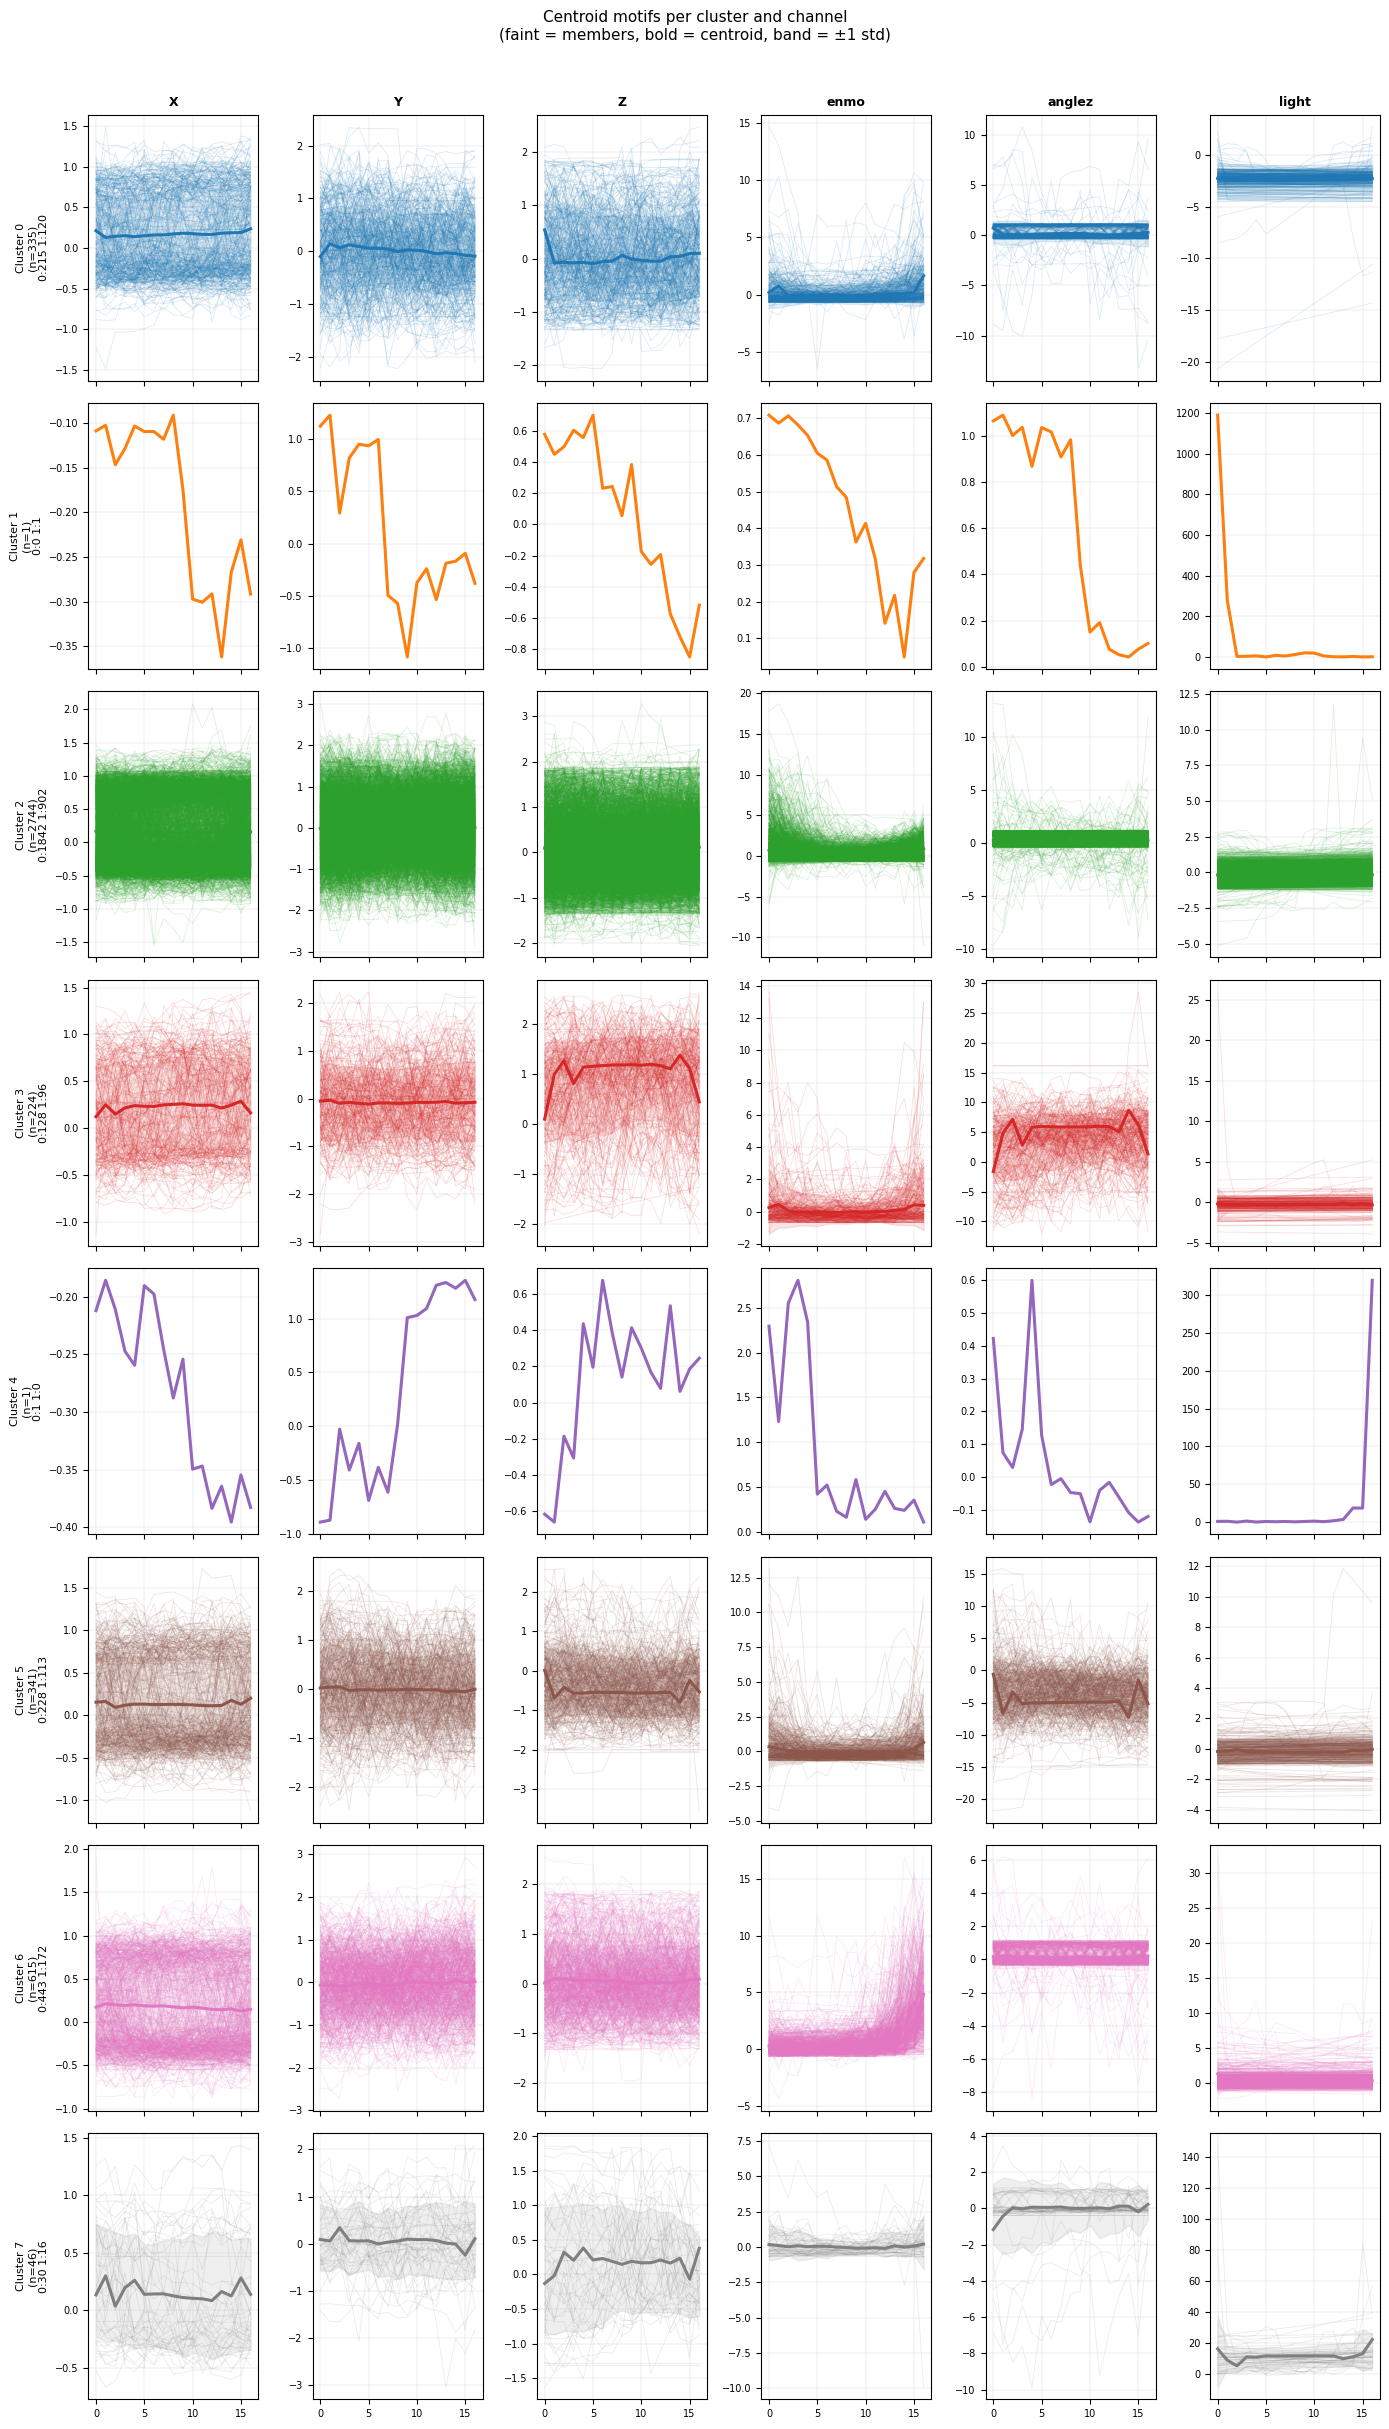

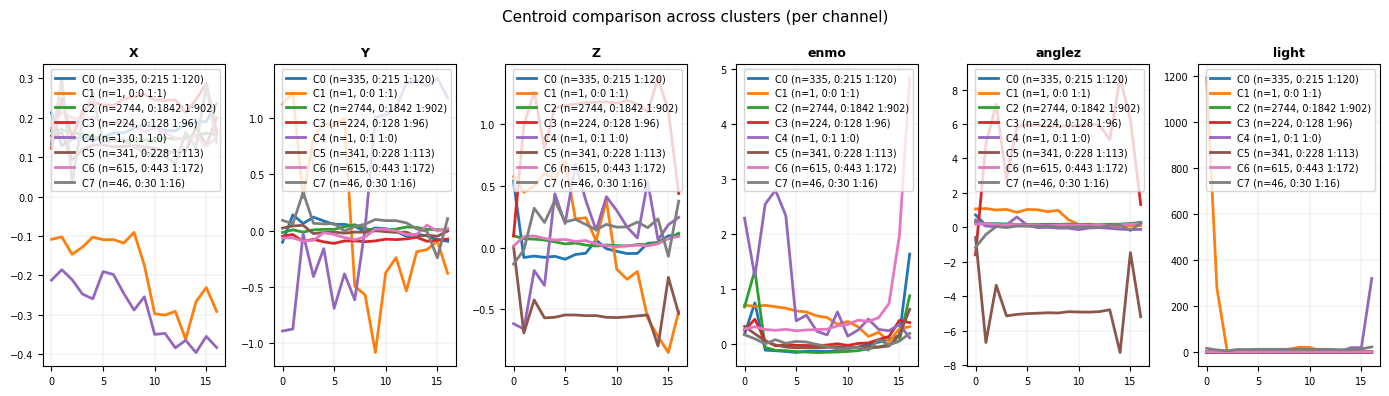

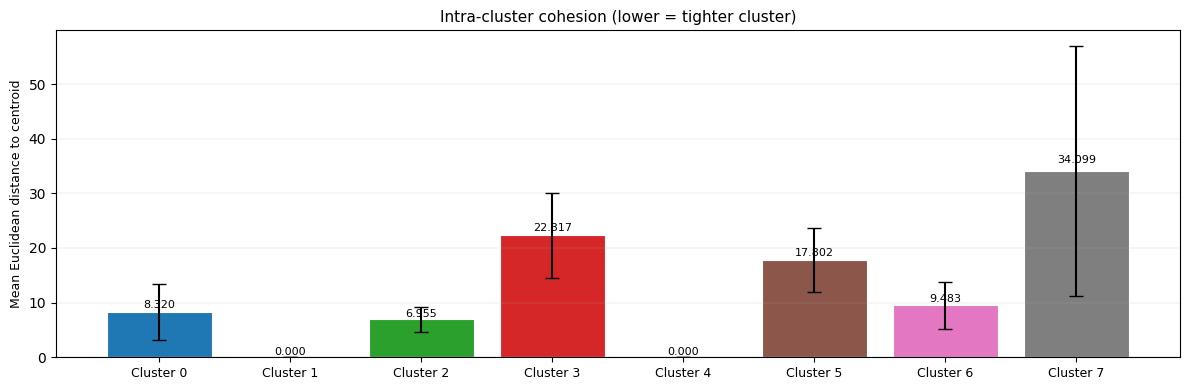

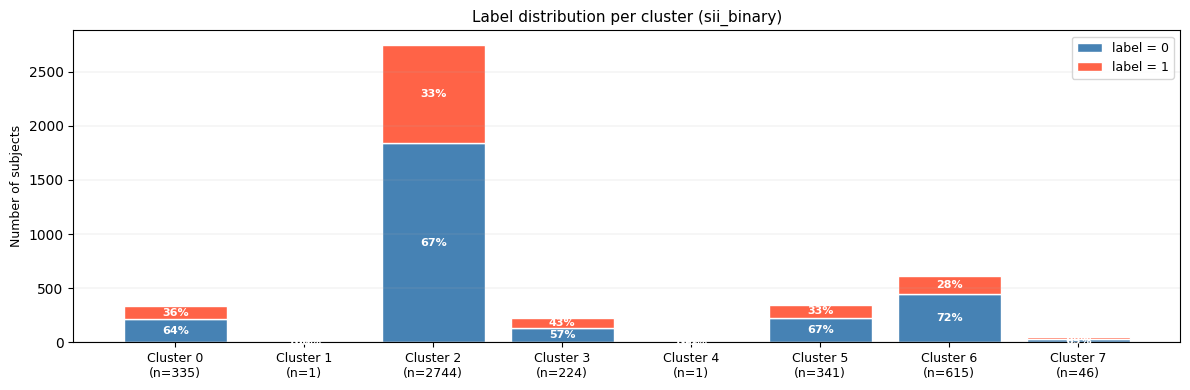

{0: {'mean_dist': np.float64(8.319542846790208),
  'std_dist': np.float64(5.113325578606696),
  'max_dist': np.float64(60.32627716667548),
  'min_dist': np.float64(4.16178119870467)},
 1: {'mean_dist': np.float64(0.0),
  'std_dist': np.float64(0.0),
  'max_dist': np.float64(0.0),
  'min_dist': np.float64(0.0)},
 2: {'mean_dist': np.float64(6.955077421514026),
  'std_dist': np.float64(2.3182369131088887),
  'max_dist': np.float64(37.099446183018266),
  'min_dist': np.float64(3.3190640918912657)},
 3: {'mean_dist': np.float64(22.317088347034513),
  'std_dist': np.float64(7.834159274353496),
  'max_dist': np.float64(47.4818281124801),
  'min_dist': np.float64(10.40778168772581)},
 4: {'mean_dist': np.float64(0.0),
  'std_dist': np.float64(0.0),
  'max_dist': np.float64(0.0),
  'min_dist': np.float64(0.0)},
 5: {'mean_dist': np.float64(17.80174069097309),
  'std_dist': np.float64(5.84454057512767),
  'max_dist': np.float64(51.425034239279924),
  'min_dist': np.float64(7.659546700450629)},


In [24]:
characterize_clusters(
    motifs_df   = motifs_df,
    X_3d        = X_3d,
    km_final    = km_final,
    CHANNELS    = CHANNELS,
    best_k      = best_k,
    y_labels    = y_labels.astype(int),   # ← pass here
)

In [25]:
# 9e. Save cluster membership table (optional)
membership_df = motifs_df[["sample_index", "cluster"]].copy()
# membership_df.to_csv("subject_clusters.csv", index=False)
# print("\n💾 Cluster assignments saved → subject_clusters.csv")

# 9f. Save centroid arrays (optional)
# np.save("cluster_centroids.npy", centroids)
# print("💾 Centroids saved → cluster_centroids.npy")


--- Visualizing cluster centroids ---


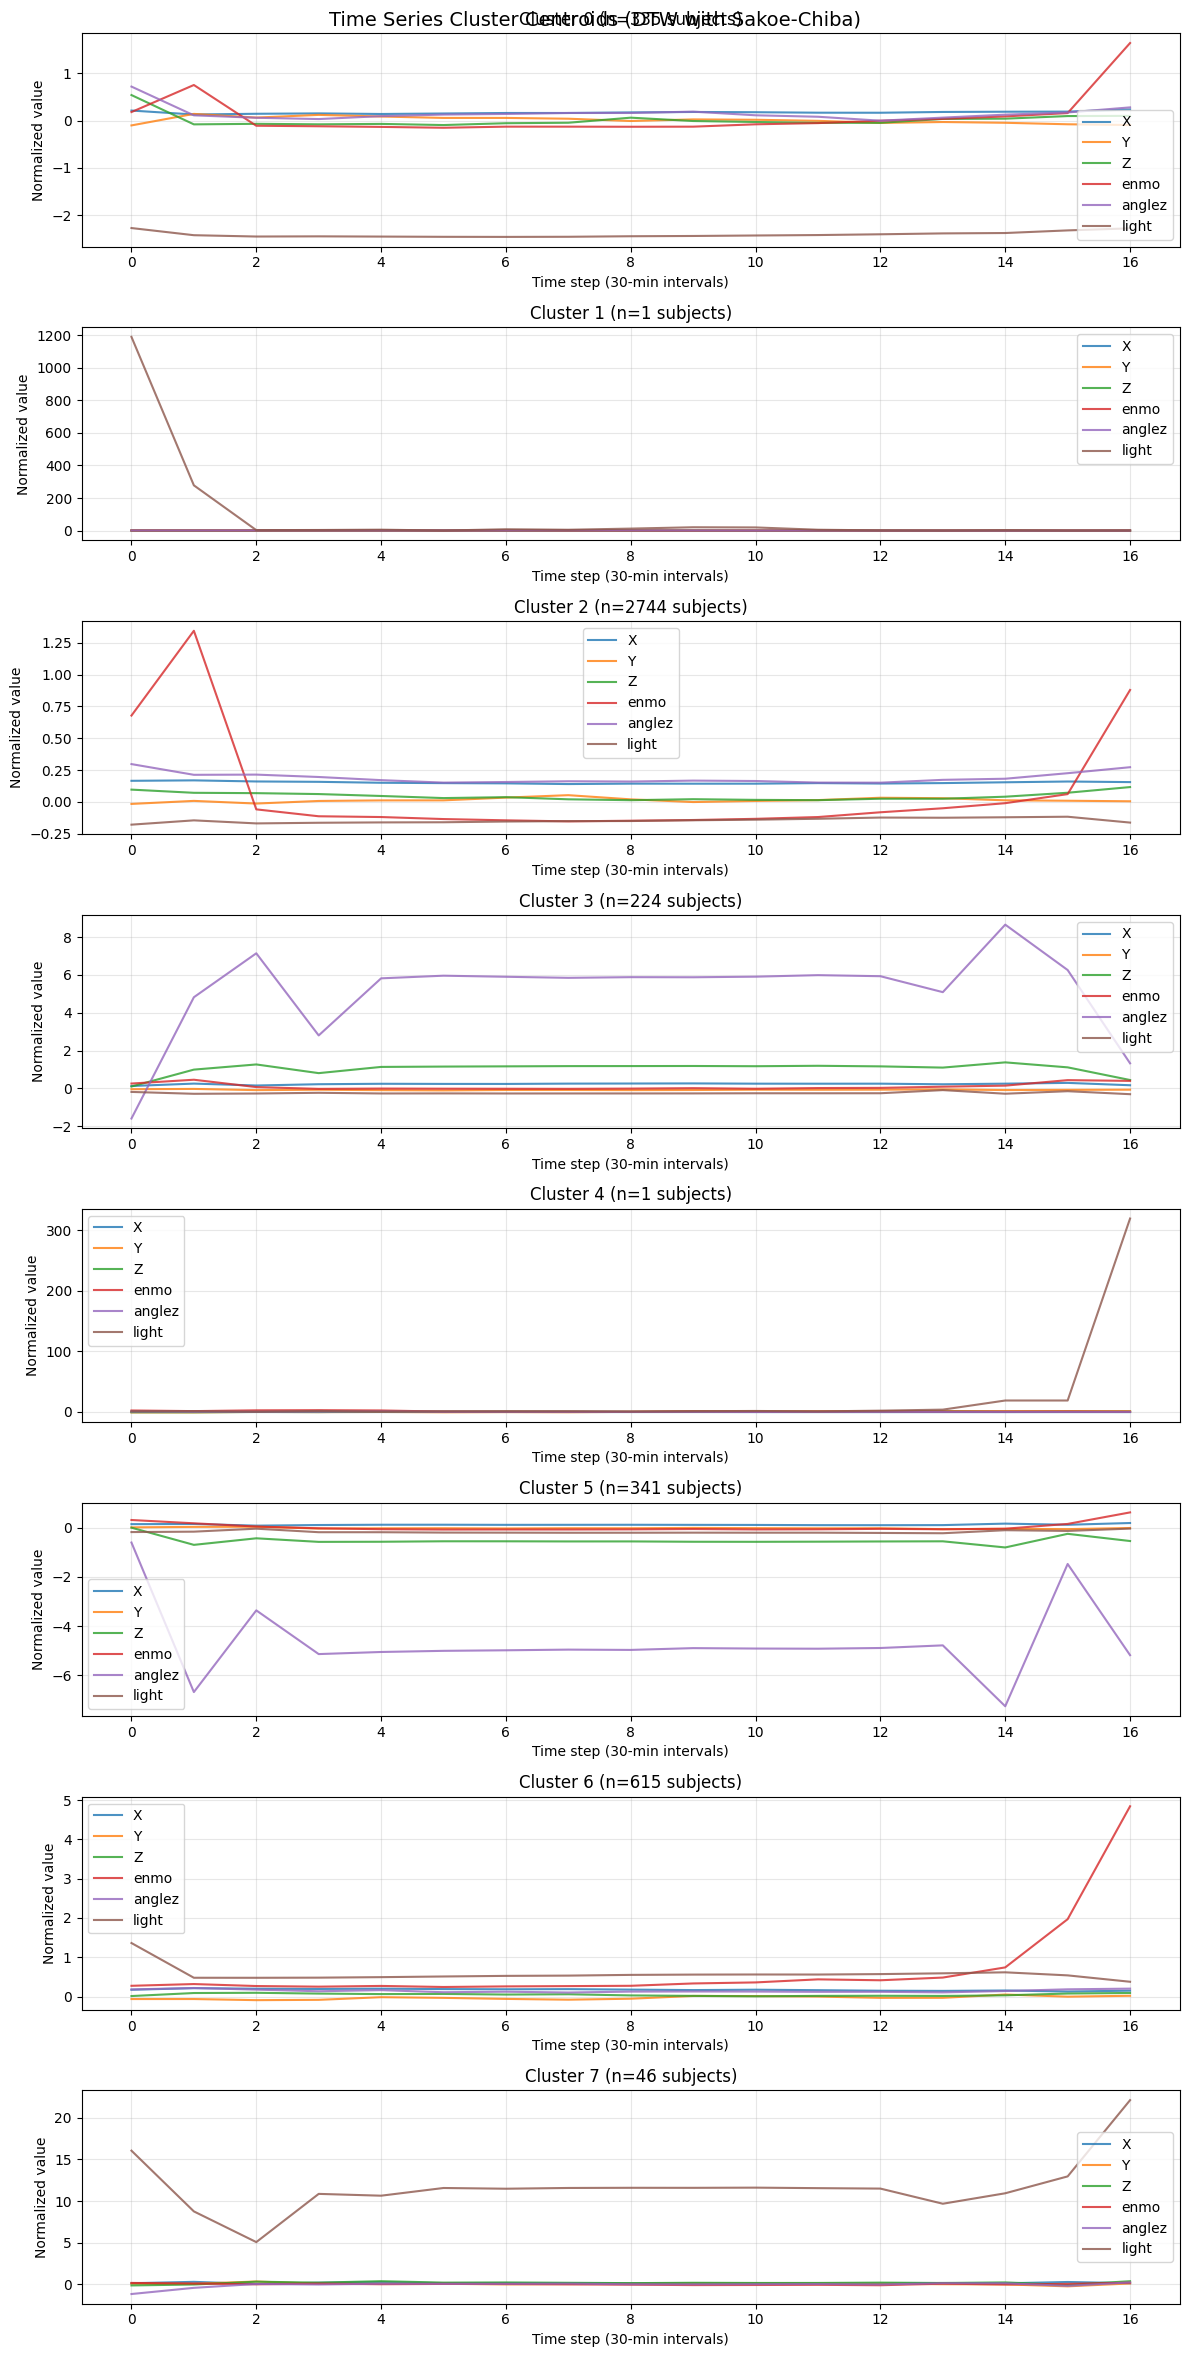

In [26]:
import matplotlib.pyplot as plt

print("\n--- Visualizing cluster centroids ---")

fig, axes = plt.subplots(best_k, 1, figsize=(12, 3*best_k))

if best_k == 1:
    axes = [axes]

for c in range(best_k):
    for i, ch in enumerate(CHANNELS):
        axes[c].plot(centroids[c, :, i], label=ch, alpha=0.8)
    
    axes[c].set_title(f'Cluster {c} (n={cluster_counts[c]} subjects)')
    axes[c].set_xlabel('Time step (30-min intervals)')
    axes[c].set_ylabel('Normalized value')
    axes[c].legend()
    axes[c].grid(True, alpha=0.3)

plt.suptitle('Time Series Cluster Centroids (DTW with Sakoe-Chiba)', fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)
 
# — 9a. Cluster sizes
print("\n--- Cluster sizes ---")
cluster_counts = motifs_df["cluster"].value_counts().sort_index()
for c, n in cluster_counts.items():
    pct = 100 * n / len(motifs_df)
    print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")
 
# — 9b. Subject indices per cluster
print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in range(best_k):
    members = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
    print(f"  Cluster {c} ({len(members)} subjects): {members[:10]}{'...' if len(members) > 10 else ''}")
 
# — 9c. Centroids  (shape: best_k, W, n_channels)
#        km_final.cluster_centers_ is already the mean motif per cluster
centroids = km_final.cluster_centers_   # (best_k, W, n_channels)
print(f"\n--- Centroid shapes: {centroids.shape}  (n_clusters, W, n_channels) ---")
 
# — 9d. Per-cluster centroid stats across channels
print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
for c in range(best_k):
    print(f"\n  Cluster {c}:")
    for i, ch in enumerate(CHANNELS):
        vals = centroids[c, :, i]
        print(f"    {ch:>8s}:  mean={vals.mean():.4f}  std={vals.std():.4f}"
              f"  min={vals.min():.4f}  max={vals.max():.4f}")
 
# — 9e. Save cluster membership table
membership_df = motifs_df[["sample_index", "cluster"]].copy()
#membership_df.to_csv("subject_clusters.csv", index=False)
#print("\nCluster assignments saved → subject_clusters.csv")
 
# — 9f. Save centroid arrays
#np.save("cluster_centroids.npy", centroids)
#print("Centroids saved → cluster_centroids.npy")


CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:  335 subjects  (7.8%)
  Cluster 1:    1 subjects  (0.0%)
  Cluster 2: 2744 subjects  (63.7%)
  Cluster 3:  224 subjects  (5.2%)
  Cluster 4:    1 subjects  (0.0%)
  Cluster 5:  341 subjects  (7.9%)
  Cluster 6:  615 subjects  (14.3%)
  Cluster 7:   46 subjects  (1.1%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster 0 (335 subjects): [18, 19, 28, 61, 65, 83, 86, 95, 108, 109]...
  Cluster 1 (1 subjects): [2646]
  Cluster 2 (2744 subjects): [0, 1, 2, 3, 5, 6, 7, 8, 9, 10]...
  Cluster 3 (224 subjects): [24, 25, 39, 62, 71, 94, 98, 118, 148, 171]...
  Cluster 4 (1 subjects): [916]
  Cluster 5 (341 subjects): [13, 22, 26, 64, 68, 88, 92, 129, 134, 145]...
  Cluster 6 (615 subjects): [4, 34, 36, 41, 45, 46, 48, 55, 58, 66]...
  Cluster 7 (46 subjects): [38, 215, 301, 358, 418, 428, 473, 484, 597, 741]...

--- Centroid shapes: (8, 17, 6)  (n_clusters, W, n_channels) ---

--- Centroid summary (mean ± std across time steps, 

## visualise

In [28]:
X_flat = X_3d.reshape(len(X_3d), -1)   # flatten only for PCA / t-SNE
CMAP   = "tab10"

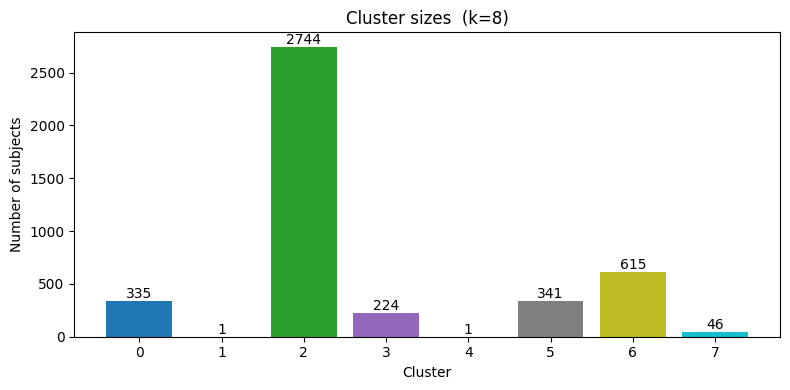

In [29]:
 
# ── 10b. Cluster size bar chart ───────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_counts.index, cluster_counts.values,
              color=plt.cm.tab10(np.linspace(0, 1, best_k)))
ax.bar_label(bars, fmt="%d")
ax.set_xlabel("Cluster"); ax.set_ylabel("Number of subjects")
ax.set_title(f"Cluster sizes  (k={best_k})")
ax.set_xticks(range(best_k))
plt.tight_layout()
#plt.savefig("02_cluster_sizes.png", dpi=150)
plt.show()
#print("Saved → 02_cluster_sizes.png")

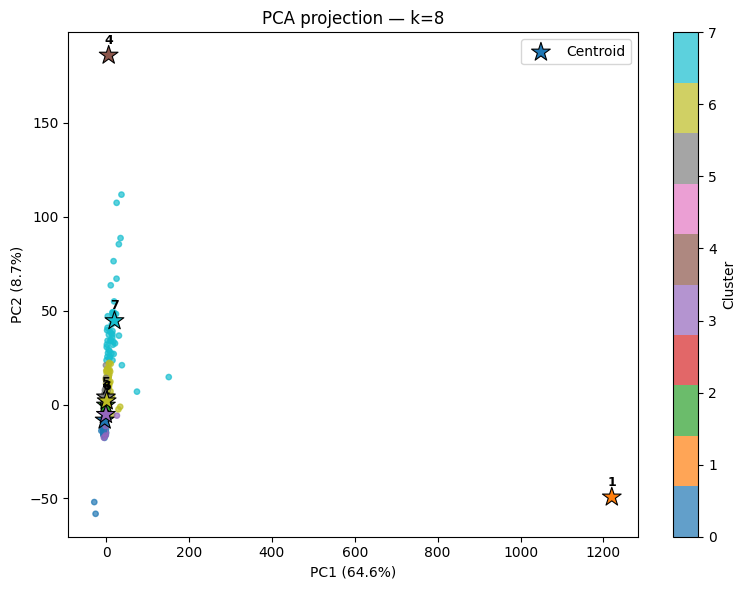

In [30]:
# ── 10c. PCA scatter ─────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)
 
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
# mark centroids in PCA space
cents_flat  = centroids.reshape(best_k, -1)
cents_pca   = pca.transform(cents_flat)
ax.scatter(cents_pca[:, 0], cents_pca[:, 1],
           c=range(best_k), cmap=CMAP,
           s=200, marker="*", edgecolors="black", linewidths=0.8,
           label="Centroid", zorder=5)
for c in range(best_k):
    ax.annotate(str(c), cents_pca[c], fontsize=9, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 6), textcoords="offset points")
ax.set_title(f"PCA projection — k={best_k}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=ax, label="Cluster")
ax.legend()
plt.tight_layout()
#plt.savefig("03_pca_scatter.png", dpi=150)
plt.show()
#print("Saved → 03_pca_scatter.png")

Running t-SNE (this may take a minute) ...


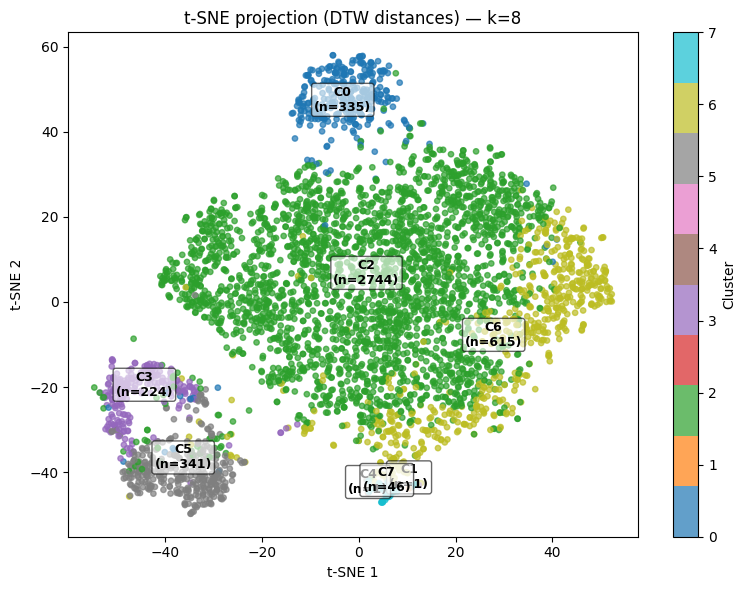

In [31]:
# ── 10d. t-SNE scatter ───────────────────────
print("Running t-SNE (this may take a minute) ...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              metric="precomputed", init="random")
X_tsne = tsne.fit_transform(dist_mat)   # uses the real DTW distances
 
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)
# annotate cluster centres in t-SNE space (mean position of members)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy),
                fontsize=9, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
ax.set_title(f"t-SNE projection (DTW distances) — k={best_k}")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

Running t-SNE (this may take a minute) ...


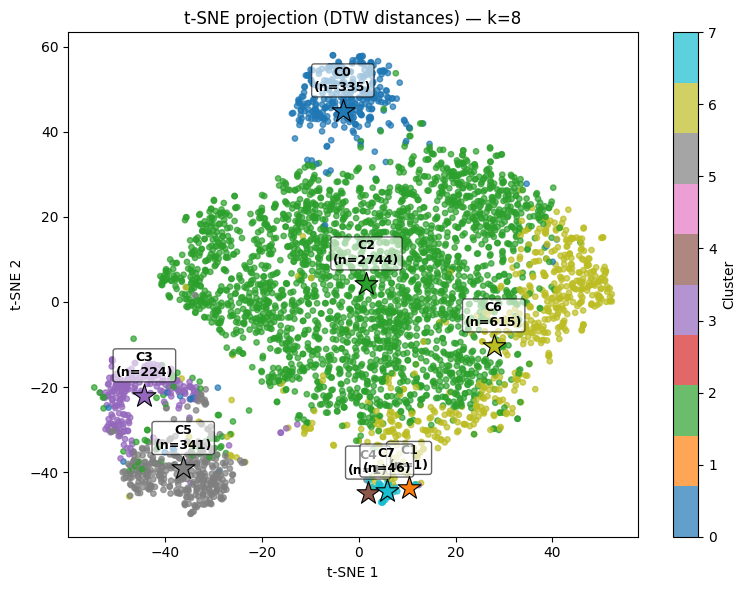

In [32]:
# ── 10d. t-SNE scatter ───────────────────────
print("Running t-SNE (this may take a minute) ...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              metric="precomputed", init="random")
X_tsne = tsne.fit_transform(dist_mat)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7)

# annotate cluster centres in t-SNE space (mean position of members)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()

    # ── centroid marker ──────────────────────
    ax.scatter(cx, cy, marker="*", s=300,
               c=[c], cmap=CMAP, vmin=0, vmax=best_k - 1,
               edgecolors="black", linewidths=0.8, zorder=5)
    # ── label ───────────────────────────────
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy),
                xytext=(0, 14), textcoords="offset points",
                fontsize=9, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

ax.set_title(f"t-SNE projection (DTW distances) — k={best_k}")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

# DBSCAN

## k distance plot (choose k visually)

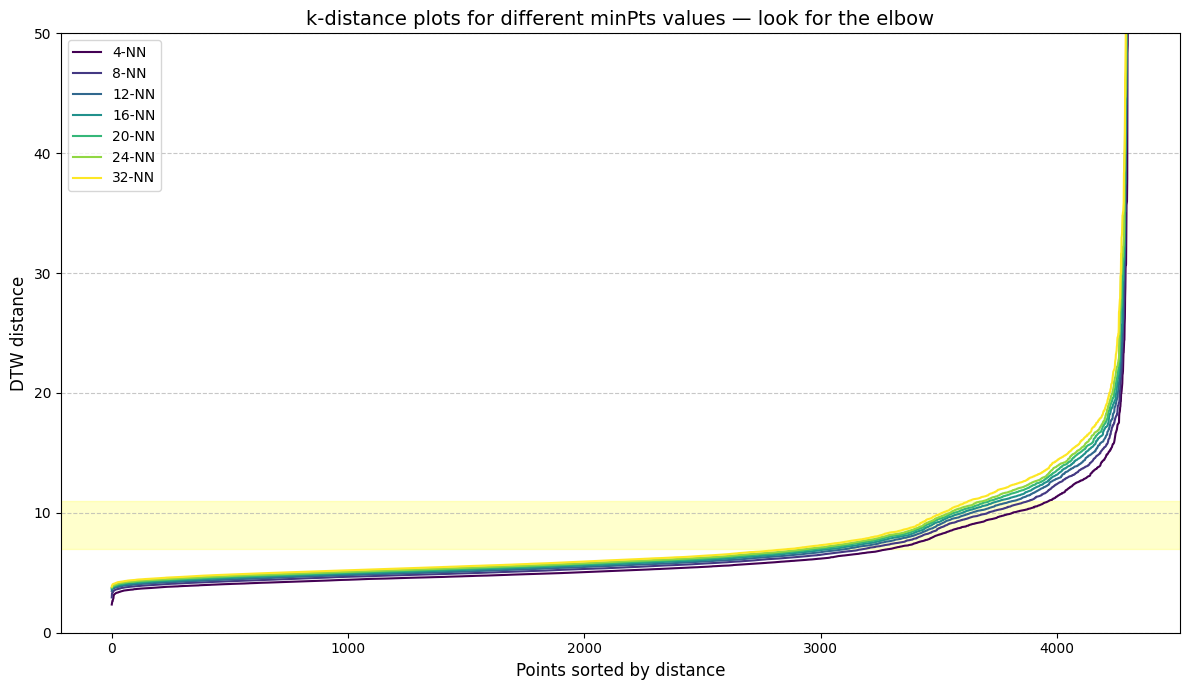

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Test multiple minPts values
minPts_values = [4, 8, 12, 16, 20, 24, 32]

# Use the precomputed DTW dist_mat directly
sorted_dists = np.sort(dist_mat, axis=1)  # for each point, sorted distances to all others

# Plot all curves
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.viridis(np.linspace(0, 1, len(minPts_values)))

for idx, min_pts in enumerate(minPts_values):
    kth_dists = np.sort(sorted_dists[:, min_pts])  # k-th nearest neighbour distance
    ax.plot(kth_dists, color=colors[idx], linewidth=1.5, label=f'{min_pts}-NN')

ax.set_xlabel("Points sorted by distance", fontsize=12)
ax.set_ylabel("DTW distance", fontsize=12)
ax.set_title("k-distance plots for different minPts values — look for the elbow", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend(loc='best', fontsize=10)
ax.set_ylim(0, 50)  # Optional: set y-axis limit

# Add shadow/band between 8 and 13 on y-axis
ax.axhspan(ymin=7, ymax=11, alpha=0.2, color='yellow')

# Add text label for the band

plt.tight_layout()
plt.show()


## sweep min_samples

  min_samples=    2  clusters=14  noise=477  silhouette=0.1495
  min_samples=    4  clusters=2  noise=522  silhouette=0.5100
  min_samples=    8  clusters=2  noise=595  silhouette=0.5010
  min_samples=   16  → no valid clusters, skipped
  min_samples=   32  → no valid clusters, skipped
  min_samples=   64  → no valid clusters, skipped
  min_samples=  128  → no valid clusters, skipped
  min_samples=  256  → no valid clusters, skipped
  min_samples=  512  → no valid clusters, skipped
  min_samples= 1024  → no valid clusters, skipped


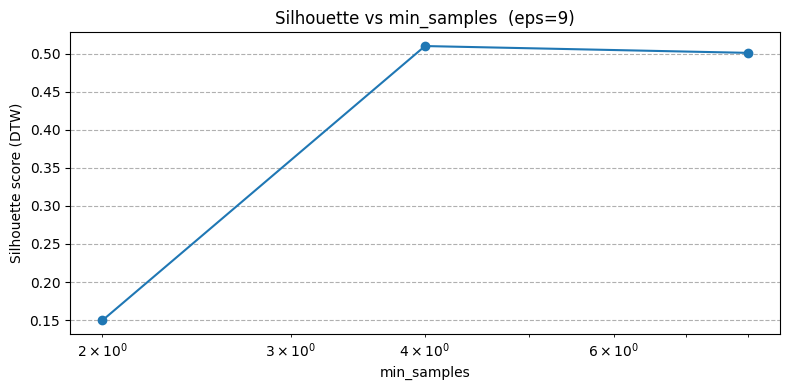

In [34]:
minpts_range = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
sil_list     = []
valid_minpts = []
EPS=9
 
for minpts in minpts_range:
    db = DBSCAN(eps=EPS, min_samples=minpts, metric="precomputed")
    db.fit(dist_mat)
 
    non_noise  = db.labels_ != -1
    n_clusters = len(set(db.labels_[non_noise]))
 
    if non_noise.sum() > 1 and n_clusters > 1:
        sil = silhouette_score(dist_mat[np.ix_(non_noise, non_noise)],
                               db.labels_[non_noise],
                               metric="precomputed")
        sil_list.append(sil)
        valid_minpts.append(minpts)
        print(f"  min_samples={minpts:5d}  clusters={n_clusters}  "
              f"noise={( ~non_noise).sum()}  silhouette={sil:.4f}")
    else:
        print(f"  min_samples={minpts:5d}  → no valid clusters, skipped")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(valid_minpts, sil_list, "o-")
ax.set_xlabel("min_samples"); ax.set_ylabel("Silhouette score (DTW)")
ax.set_title(f"Silhouette vs min_samples  (eps={EPS})")
ax.set_xscale("log"); ax.grid(linestyle="--")
plt.tight_layout()
#plt.savefig("07_dbscan_silhouette_sweep.png", dpi=150)
plt.show()
#print("Saved → 07_dbscan_silhouette_sweep.png")

## final dbscan

In [35]:
best_minpts = 2
 
db_final       = DBSCAN(eps=EPS, min_samples=best_minpts, metric="precomputed")
db_final.fit(dist_mat)
cluster_labels = db_final.labels_
 
non_noise_mask = cluster_labels != -1
n_noise        = (~non_noise_mask).sum()
unique_labels  = sorted(set(cluster_labels))
n_clusters     = len([l for l in unique_labels if l != -1])
 
sil_final = silhouette_score(
    dist_mat[np.ix_(non_noise_mask, non_noise_mask)],
    cluster_labels[non_noise_mask],
    metric="precomputed"
)
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise}  ({100*n_noise/len(cluster_labels):.1f}%)")
print(f"  Silhouette     : {sil_final:.4f}")
 
motifs_df["cluster_dbscan"] = cluster_labels

  Clusters found : 14
  Noise points   : 477  (11.1%)
  Silhouette     : 0.1495


## cluster analysis

In [36]:
print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)
 
print("\n--- Cluster sizes (label -1 = noise) ---")
cluster_counts = motifs_df["cluster_dbscan"].value_counts().sort_index()
for c, n in cluster_counts.items():
    tag = " [NOISE]" if c == -1 else ""
    print(f"  Cluster {c:>3d}{tag}: {n:4d} subjects  ({100*n/len(motifs_df):.1f}%)")
 
print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in unique_labels:
    members = motifs_df.loc[motifs_df["cluster_dbscan"] == c, "sample_index"].tolist()
    tag = " [NOISE]" if c == -1 else ""
    print(f"  Cluster {c}{tag} ({len(members)} subjects): "
          f"{members[:10]}{'...' if len(members) > 10 else ''}")
 
# Pseudo-centroids: subject closest to the mean DTW distance in each cluster
print("\n--- Pseudo-centroids (most central subject per cluster) ---")
for c in unique_labels:
    if c == -1:
        continue
    mask       = np.where(cluster_labels == c)[0]
    sub_dist   = dist_mat[np.ix_(mask, mask)]
    mean_dists = sub_dist.mean(axis=1)
    central_i  = mask[np.argmin(mean_dists)]
    print(f"  Cluster {c}: most central subject = sample_index "
          f"{motifs_df.iloc[central_i]['sample_index']}  "
          f"(avg DTW dist to cluster = {mean_dists.min():.4f})")
 
motifs_df[["sample_index", "cluster_dbscan"]].to_csv(
    "subject_clusters_dbscan.csv", index=False)
print("\nCluster assignments saved → subject_clusters_dbscan.csv")


CLUSTER ANALYSIS

--- Cluster sizes (label -1 = noise) ---
  Cluster  -1 [NOISE]:  477 subjects  (11.1%)
  Cluster   0: 3774 subjects  (87.6%)
  Cluster   1:   26 subjects  (0.6%)
  Cluster   2:    3 subjects  (0.1%)
  Cluster   3:    2 subjects  (0.0%)
  Cluster   4:    5 subjects  (0.1%)
  Cluster   5:    2 subjects  (0.0%)
  Cluster   6:    2 subjects  (0.0%)
  Cluster   7:    2 subjects  (0.0%)
  Cluster   8:    2 subjects  (0.0%)
  Cluster   9:    3 subjects  (0.1%)
  Cluster  10:    2 subjects  (0.0%)
  Cluster  11:    2 subjects  (0.0%)
  Cluster  12:    3 subjects  (0.1%)
  Cluster  13:    2 subjects  (0.0%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster -1 [NOISE] (477 subjects): [13, 22, 24, 28, 39, 46, 62, 68, 71, 82]...
  Cluster 0 (3774 subjects): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
  Cluster 1 (26 subjects): [25, 238, 385, 530, 583, 846, 857, 879, 1068, 1247]...
  Cluster 2 (3 subjects): [38, 473, 3058]
  Cluster 3 (2 subjects): [306, 1138]
  Cluster 4 (5 